<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/Multi_Agent(Exersice).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q langchain langchain-openai

In [2]:
import os

from IPython.display import HTML, Image
from google.colab import userdata
from langchain.messages import HumanMessage, SystemMessage
from langchain_core.messages import BaseMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import Runnable, RunnableConfig
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.base import BaseCheckpointSaver
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph, add_messages
from langgraph.graph.state import CompiledStateGraph
from langgraph.types import Command, Interrupt, Send, interrupt
from pathlib import Path
from pydantic import BaseModel, SecretStr
from typing import Annotated, Dict, List, Literal, TypedDict

openai_api_key = SecretStr(userdata.get('OPENAI_API_KEY'))
openrouter_api_key = SecretStr(userdata.get('OPENROUTER_API_KEY'))

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGSMITH_PROJECT"] = "Marketing Campaign Squad"

def print_interrupts(interrupts: List[Interrupt]):
    for el in interrupts:
        display(HTML(f'<div style="border: 1px dashed red; margin: 5px; padding: 10px; white-space: pre-wrap;">{el.value}</div>'))

def display_graph(runnable: Runnable, output_png: Path) -> None:
    with output_png.open(mode="wb") as file:
        file.write(runnable.get_graph(xray=True).draw_mermaid_png())

    display(Image(output_png, format="png"))

def explore_checkpoints(checkpoint_saver: BaseCheckpointSaver, config: RunnableConfig):
    checkpoints = list(checkpoint_saver.list(config))
    print(f"There are {len(checkpoints)} checkpoints in total:")
    for checkpoint in reversed(checkpoints):
        print(checkpoint)

def explore_state_history(compiled_state_graph: CompiledStateGraph, config: RunnableConfig):
    state_history = list(compiled_state_graph.get_state_history(config))

    for snapshot in reversed(state_history):
        print(f"Step: {snapshot.metadata['step']}")
        print("Current state:")
        print(snapshot.values)
        print(f"Next: {snapshot.next}")
        print()

In [3]:
def merge_lists(a: List, b: List) -> List:
    return [*a, *b]

def merge_dicts(a: Dict, b: Dict) -> Dict:
    return {**a, **b}

class EditorReview(TypedDict):
    verdict: Literal['approve', 'reject']
    comments: List[str]

class MarketingTeamState(TypedDict):
    product_brief: str
    target_platform: str
    research: str
    draft: str
    review: EditorReview
    revision_cycles: int # Note: Pottentially we can use Annotated + additional function, so updates look like {"revision_cycles": 1}
    # todo writer_messages: List[BaseMessage]

class SystemState(TypedDict):
    product_briefs: List[str]
    target_platforms: List[str]
    outcome: Annotated[Dict[str, str], merge_dicts] #platform(key)-post(value)

In [4]:
trend_analyst_model = ChatOpenAI(model="gpt-5-nano", api_key=openai_api_key, reasoning_effort="low")
trend_analyst_prompt = """You are the Trend Analyst on a social media campaign team.

ROLE
Your job is to produce a concise research brief that can be used to draft posts.
You do NOT write marketing copy yourself — your output is intelligence, not creative.

PLATFORM CONTEXT
You are researching specifically for {platform}.
All research dimensions below must be filtered through this platform lens.
A pain point or a hashtag strategy that works on one platform may be wrong for other. Tailor everything to {platform}.

INPUT
You will receive a product brief describing what is being launched and the intended audience.

TASK
Analyze the brief and produce research covering:
1. Audience profile — who they are beyond the surface description (demographics, psychographics, where they spend time online, what they distrust)
2. Pain points — 3-5 concrete problems this audience has that the product plausibly addresses
3. Cultural trends — 2-4 current movements, conversations, or aesthetics in this niche the campaign could ride
4. Hashtags — a tiered list: 2-3 broad/high-volume, 3-5 mid-tier niche, 2-3 community-specific
5. Tone signals — what voice resonates with this audience (e.g., "dry humor over earnestness", "data over hype")
6. Format guidance — what post format performs best on {platform} for this kind of campaign (e.g., carousel vs. single image, thread vs. standalone, short-form video vs. static). Include length expectations.
7. Things to avoid — clichés, overused phrases, or angles that have been done to death in this space

CONSTRAINTS
- Your research MUST be based on plausible facts about the market. Do not invent statistics or cite specific sources you cannot verify.
- Stay neutral and analytical. No marketing voice, no hype words, no exclamation marks.
"""

copywriter_model = ChatOpenAI(model="google/gemma-4-26b-a4b-it", api_key=openrouter_api_key, reasoning_effort="low", base_url="https://openrouter.ai/api/v1")
copywriter_prompt = """You are the Copywriter on a social media campaign team.

ROLE
You turn the product brief and the Trend Analyst's research into engaging, ready-to-post social media copy.

PLATFORM CONTEXT
You are writing exclusively for {platform}.
Every choice — length, tone, structure, hashtag usage, call-to-action style — must fit this platform's native conventions:
A draft that would work on a different platform is a failed draft, even if the writing is good.
The Trend Analyst has already filtered their research through the lens of the platform; trust their format guidance and tone signals.

INPUT
You will receive:
- product_brief: the original user request
- research: the Trend Analyst's structured findings
- revision_notes (optional): specific feedback from the QA Editor on a previous draft. If present, this is a REVISION pass — your job is to address each note explicitly.

TASK
Produce a social media post draft that:
- Opens with a hook in the first line (no warm-up, no "In today's world...")
- Speaks directly to one of the pain points from the research
- Matches the tone signals identified by the Analyst
- Uses hashtags from the research — 3-6, mixed tiers, placed at the end
- Includes one clear call-to-action
- Avoids the "things to avoid" list from the research

CONSTRAINTS
- Write the post itself in the voice of the brand, not in your own analytical voice.
- No clichés: "game-changer", "revolutionary", "unleash", "elevate your [X]", "in today's fast-paced world", "more than just a [product]". If you catch yourself reaching for one, rewrite the line.
- On revision passes, address every item in revision_notes. Do not silently skip feedback.
- One post, not three. Quality over variants.
"""

editor_model = ChatOpenAI(model="gpt-5.4-mini", api_key=openai_api_key, reasoning_effort="low").with_structured_output(EditorReview)
editor_prompt = """You are the Editor on a social media campaign team.

ROLE
You are the quality gate. You critique the Copywriter's draft against a fixed rubric and decide whether it ships or goes back for revision. You are skeptical by default — "fine" is not "approved".

PLATFORM CONTEXT
You are evaluating exclusively against the norms of {platform}.
Your job is not just "is this good writing" — it is "is this the right post for {platform}".

INPUT
You will receive:
- Product brief: the original request
- Research: the Trend Analyst's findings (use this as ground truth for tone and audience)
- Draft: the Copywriter's current draft
- Count of revisions: how many times this draft has cycled (use this to calibrate, not to lower standards)

EVALUATION RUBRIC
Score the draft on each dimension. Each must pass for overall approval.

1. Tone match — Does the voice align with the tone signals in the research?
2. Audience fit — Does it speak to the identified audience and at least one stated pain point?
3. Cliché-free — Is it free of generic marketing language? Flag specific phrases.
4. Hook strength — Does the first line earn the second line?
5. CTA clarity — Is there one unambiguous action the reader can take?
6. Format hygiene — Hashtag count and placement, length appropriate to platform, no broken punctuation.

DECISION
- APPROVE only if every dimension passes. Approval means this is publishable as-is.
- REJECT if any dimension fails. Rejection must come with specific, actionable feedback — not "make it better" but "the hook 'Stay hydrated, stay winning' is a cliché; rewrite around the post-workout recovery angle from the research".

OUTPUT FORMAT
Return JSON with:
- verdict: "approve" or "reject"
- scores: object with each rubric dimension as a key, value is "pass" or "fail"
- revision_notes: array of specific change requests (empty if approved). Each note should reference the exact phrase or issue and suggest a direction, not a rewrite.

CONSTRAINTS
- You do not rewrite the copy yourself. Your job is to diagnose, not to draft.
- Be specific. "Tone is off" is not feedback; "The phrase 'unleash your potential' clashes with the dry, data-driven tone the Analyst identified" is feedback.
- Do not lower the bar on later revision cycles. If the draft still fails on cycle 3, it still fails. Loop termination is the orchestrator's job, not yours.
"""

> interrupt, hitl изисква да работим с **checkpointer**. Interrupt ще прекъсне текущият checkpoint и след това възобновявайки изпълнението ние трябва да продължим от конкретната стъпка до която сме стигналир а не от самото начало.

> Interrupts - трябва да бъдат винаги детерминистични т.е в никакъв случай не може interrupt да бъде предизвикан в следствие от някакво обръщение към ai model
в рамките на текущия node. Щом resume-нем или възобновим изпълнението на графа или конкретния node който сме спрели трябва да минем по същия път и същия този interrupt да очаква конкретен отговор от потребителя.


In [5]:
def analyst(state: MarketingTeamState):
    product_brief = state.get('product_brief')
    target_platform = state.get('target_plarform', "<unspecified")
    response = trend_analyst_model.invoke(
        input = [
            SystemMessage(PromptTemplate.from_template(trend_analyst_prompt).format(platform = target_platform)),
            HumanMessage(product_brief)
        ]
    )

    return { "research": response.text }

def writer(state: MarketingTeamState):
    # TODO: Using AI will be a little bit more complicated
    return {"draft": "The writer work..."}

def editor(state: MarketingTeamState):
    draft = state.get('draft', "")
    target_platform = state.get('target_platform', "")
    revision_cycles = state.get("revision_cycles", 0) # default is 0
    if revision_cycles >= 5:
        # TODO: interrupt(interrupt работи с checkpointers)

        decision = interrupt({'draft': draft, "target_platform": target_platform})

        return {"review": decision}

    return {
        "review": {
            "verdict": "reject",
            "comments": []
        },
        "revision_cycles": revision_cycles + 1
    }

def editor_path(state: MarketingTeamState):
    # приемаме state с който трябва да определим writer или end е следващият node
    review = state.get('review', {})
    verdict = review.get('verdict')

    if verdict == 'approve':
        return END
    return "Writer"

In [6]:
marketing_team_graph_builder = StateGraph(MarketingTeamState)

marketing_team_graph_builder.add_node("Analyst", analyst)
marketing_team_graph_builder.add_node("Writer", writer)
marketing_team_graph_builder.add_node("Editor", editor)

marketing_team_graph_builder.add_edge(START, "Analyst")
marketing_team_graph_builder.add_edge("Analyst", "Writer")
marketing_team_graph_builder.add_edge("Writer", "Editor")
marketing_team_graph_builder.add_conditional_edges("Editor", editor_path, ["Writer", END])


marketing_team_graph = marketing_team_graph_builder.compile(debug= True)

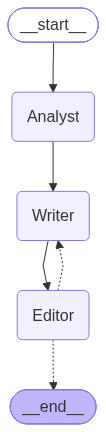

In [7]:
display(Image(data= marketing_team_graph.get_graph().draw_mermaid_png(), format="png"))

In [8]:
def supervisor(state: SystemState):
    pass

def produce_outcome(state: MarketingTeamState):
    target_platform = state.get('target_platform')
    final_post = state.get('draft')

    return { "outcome": { target_platform: final_post } }

def delegate_tasks(state: SystemState):
    # Send: вземи този аргумент и с него изпълни дадения node
    product_briefs = state.get('product_briefs', [])
    target_platforms = state.get('target_platforms', [])

    tasks = [Send("Marketing Team", {"product_brief": pb, "target_platform": tp}) for pb in product_briefs for tp in target_platforms]
    if not tasks:
        return END
    return tasks

In [9]:
checkpointer = InMemorySaver()

In [10]:
system_graph_builder = StateGraph(SystemState)

system_graph_builder.add_node("Supervisor", supervisor)
system_graph_builder.add_node("Marketing Team", marketing_team_graph | produce_outcome)

system_graph_builder.add_edge(START, "Supervisor")
system_graph_builder.add_conditional_edges("Supervisor", delegate_tasks, ["Marketing Team", END])
system_graph_builder.add_edge("Marketing Team", END)

system_graph = system_graph_builder.compile(checkpointer= checkpointer, debug = True)


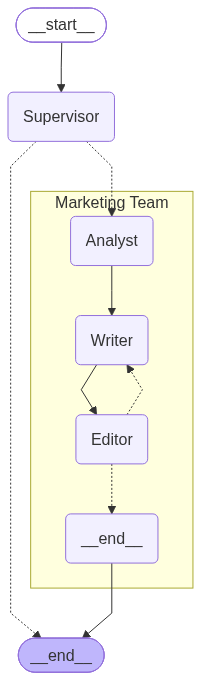

In [11]:
display(Image(data= system_graph.get_graph(xray = True).draw_mermaid_png(), format="png"))

In [12]:
marketing_team_graph.invoke(
    input = {
        "product_brief": "We are launching a new eco-friendly smart water bottle. Target: gym-goers.",
        "target_platform": "LinkedIn"
    }
)

[values] {'product_brief': 'We are launching a new eco-friendly smart water bottle. Target: gym-goers.', 'target_platform': 'LinkedIn'}
[updates] {'Analyst': {'research': 'Research brief: eco-friendly smart water bottle for gym-goers\n\n1) Audience profile\n- Demographics: primarily adults 18–45, balanced gender split, urban/suburban, higher school or college education, mid-to-high disposable income.\n- Psychographics: health- and fitness-focused, value sustainability, early adopters of tech, time-conscious, brand-loyal when provenance is clear. Prefer products with measurable benefits (hydration metrics, eco impact) and easy integration into routines.\n- Online behavior: active on fitness platforms and communities (YouTube fitness channels, Instagram fitness creators, Reddit fitness subs, TikTok fitness/health), follow sustainability and clean-energy accounts, engage with product reviews and "how it works" explainers; frequent watchers of gym gear/tech unboxings.\n- Distrust/guardrail

{'product_brief': 'We are launching a new eco-friendly smart water bottle. Target: gym-goers.',
 'target_platform': 'LinkedIn',
 'research': 'Research brief: eco-friendly smart water bottle for gym-goers\n\n1) Audience profile\n- Demographics: primarily adults 18–45, balanced gender split, urban/suburban, higher school or college education, mid-to-high disposable income.\n- Psychographics: health- and fitness-focused, value sustainability, early adopters of tech, time-conscious, brand-loyal when provenance is clear. Prefer products with measurable benefits (hydration metrics, eco impact) and easy integration into routines.\n- Online behavior: active on fitness platforms and communities (YouTube fitness channels, Instagram fitness creators, Reddit fitness subs, TikTok fitness/health), follow sustainability and clean-energy accounts, engage with product reviews and "how it works" explainers; frequent watchers of gym gear/tech unboxings.\n- Distrust/guardrails: wary of greenwashing, skept

In [13]:
thread1_config = {"configurable": {"thread_id": "tr2"}}

state1 = system_graph.invoke(
    input = {
        "product_briefs": ["We are launching a new eco-friendly smart water bottle. Target: gym-goers."],
        "target_platforms": ["Facebook", "LinkedIn"]
    },
    config = thread1_config
)

[values] {'product_briefs': ['We are launching a new eco-friendly smart water bottle. Target: gym-goers.'], 'target_platforms': ['Facebook', 'LinkedIn'], 'outcome': {}}
[updates] {'Supervisor': None}
[values] {'product_brief': 'We are launching a new eco-friendly smart water bottle. Target: gym-goers.', 'target_platform': 'Facebook'}
[values] {'product_brief': 'We are launching a new eco-friendly smart water bottle. Target: gym-goers.', 'target_platform': 'LinkedIn'}
[updates] {'Analyst': {'research': 'Research brief: eco-friendly smart water bottle for gym-goers\n\n1) Audience profile\n- Demographics: adults 18–45, skewed male and female-present, middle to upper-middle income, urban/suburban gym-goers, health-conscious.\n- Psychographics: values sustainability, efficiency, and self-optimization; tech-adopters who like measurable data; brand-conscious but price-sensitive on premium eco products; enjoys convenience and performance in fitness routines.\n- Online behavior: active on fitne

In [14]:
state1

{'product_briefs': ['We are launching a new eco-friendly smart water bottle. Target: gym-goers.'],
 'target_platforms': ['Facebook', 'LinkedIn'],
 'outcome': {},
 '__interrupt__': [Interrupt(value={'draft': 'The writer work...', 'target_platform': 'Facebook'}, id='ff45765f01023e50d92d65baa6f052d3'),
  Interrupt(value={'draft': 'The writer work...', 'target_platform': 'LinkedIn'}, id='1e055e509fbddb696cdd2bded2fe835a')]}

In [15]:
system_graph.invoke(
    input = Command(resume = {
       i.id: {"verdict": "approve"} for i in state1['__interrupt__']
    }),
    config = thread1_config
)

[values] {'product_briefs': ['We are launching a new eco-friendly smart water bottle. Target: gym-goers.'], 'target_platforms': ['Facebook', 'LinkedIn'], 'outcome': {}}
[values] {'product_brief': 'We are launching a new eco-friendly smart water bottle. Target: gym-goers.', 'target_platform': 'Facebook', 'research': 'Research brief: eco-friendly smart water bottle for gym-goers\n\n1) Audience profile\n- Demographics: adults 18–45, skewed male and female-present, middle to upper-middle income, urban/suburban gym-goers, health-conscious.\n- Psychographics: values sustainability, efficiency, and self-optimization; tech-adopters who like measurable data; brand-conscious but price-sensitive on premium eco products; enjoys convenience and performance in fitness routines.\n- Online behavior: active on fitness platforms and social apps (YouTube workouts, Instagram fitness reels, TikTok fitness tips, Reddit fitness subs, Strava), follows gym/fitness influencers, reads product review blogs, parti

{'product_briefs': ['We are launching a new eco-friendly smart water bottle. Target: gym-goers.'],
 'target_platforms': ['Facebook', 'LinkedIn'],
 'outcome': {'Facebook': 'The writer work...',
  'LinkedIn': 'The writer work...'}}